In [1]:
!pip install kmodes

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
from sklearn.preprocessing import MinMaxScaler
from kmodes.kprototypes import KPrototypes
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.stats import chi2_contingency

df = pd.read_csv("/content/Relatorio.csv", sep=";") # Inicia o Data Frame do arquivo CSV
df_formados = df[(df["Ano de Conclusão"].notna())] # Inicia um data frame onde a coluna "Ano de Conclusão" não é nula

                            Dias Para Formar    I.R.A.     Idade  \
Dias Para Formar                    1.000000 -0.784354  0.170880   
I.R.A.                             -0.784354  1.000000 -0.221806   
Idade                               0.170880 -0.221806  1.000000   
Dias Para Defesa TCC                0.926446 -0.684861 -0.001761   
Diferença Dias P/F e D/TCC          0.390023 -0.408166  0.458210   
Renda Per Capita                   -0.064304  0.035275 -0.084039   

                            Dias Para Defesa TCC  Diferença Dias P/F e D/TCC  \
Dias Para Formar                        0.926446                    0.390023   
I.R.A.                                 -0.684861                   -0.408166   
Idade                                  -0.001761                    0.458210   
Dias Para Defesa TCC                    1.000000                    0.014718   
Diferença Dias P/F e D/TCC              0.014718                    1.000000   
Renda Per Capita                       -0.1

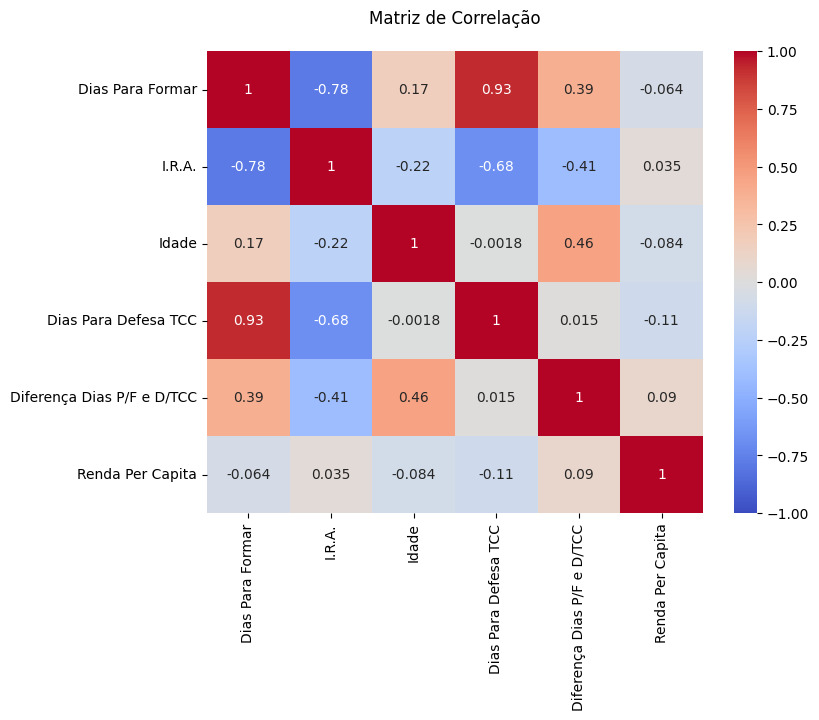

In [ ]:
# --- Matriz de Correlação Formados ---
# Define as colunas que serão utilizadas na matriz
colunas = ["Dias Para Formar",
           "I.R.A.", "Idade",
           "Dias Para Defesa TCC",
           "Diferença Dias P/F e D/TCC",
           "Renda Per Capita"]

df_matriz = df_formados[colunas] # Cria o Data Frame com essas colunas
df_matriz = df_matriz.apply(pd.to_numeric, errors='coerce') # Converte todos os valores para númericos
df_matriz = df_matriz[df_matriz["I.R.A."] > 1]
df_matriz.dropna(inplace=True)

scaler = MinMaxScaler() # Utiliaza oo Scaler para normalizar as variaveis não-categoricas
df_matriz[colunas] = scaler.fit_transform(df_matriz[colunas])

matriz_correlacao = df_matriz.corr() # Inicia a matriz de correlação
print(matriz_correlacao)

# Cria o gráfico da matriz
plt.figure(figsize=(8,6))
sns.heatmap(matriz_correlacao, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de Correlação", pad=20)
plt.savefig("Matriz_Correlação.pdf", format="pdf", bbox_inches='tight')
plt.show()
# --- Matriz de Correlação Formados ---

                    I.R.A.     Idade  Renda Per Capita
I.R.A.            1.000000 -0.247900          0.139432
Idade            -0.247900  1.000000          0.040807
Renda Per Capita  0.139432  0.040807          1.000000


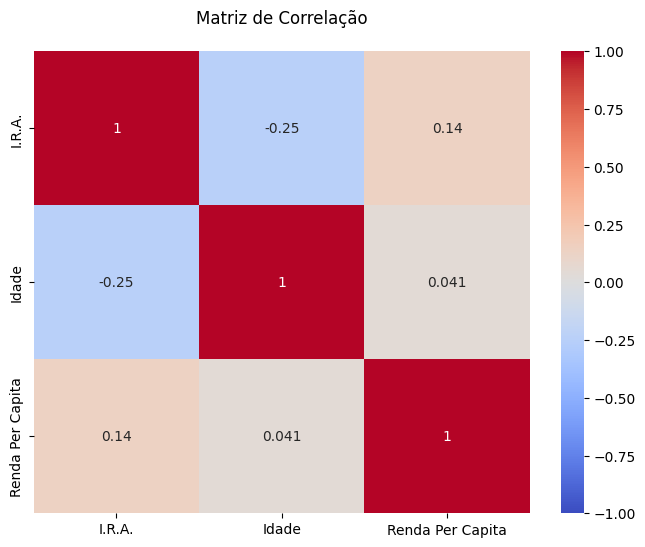

In [ ]:
# --- Matriz de Correlação Geral ---
# Define as colunas que serão utilizadas na matriz
colunas = ["I.R.A.", "Idade", "Renda Per Capita"]

df_matriz = df[colunas].copy() # Cria o Data Frame com essas colunas
df_matriz = df_matriz.apply(pd.to_numeric, errors='coerce') # Converte todos os valores para númericos
df_matriz = df_matriz[df_matriz["I.R.A."] > 1]
df_matriz.dropna(inplace=True)

scaler = MinMaxScaler() # Utiliaza oo Scaler para normalizar as variaveis não-categoricas
df_matriz[colunas] = scaler.fit_transform(df_matriz[colunas])

matriz_correlacao = df_matriz.corr() # Inicia a matriz de correlação
print(matriz_correlacao)

# Cria o gráfico da matriz
plt.figure(figsize=(8,6))
sns.heatmap(matriz_correlacao, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de Correlação", pad=20)
plt.savefig("Matriz_Correlação_Geral.pdf", format="pdf", bbox_inches='tight')
plt.show()
# --- Matriz de Correlação Geral ---

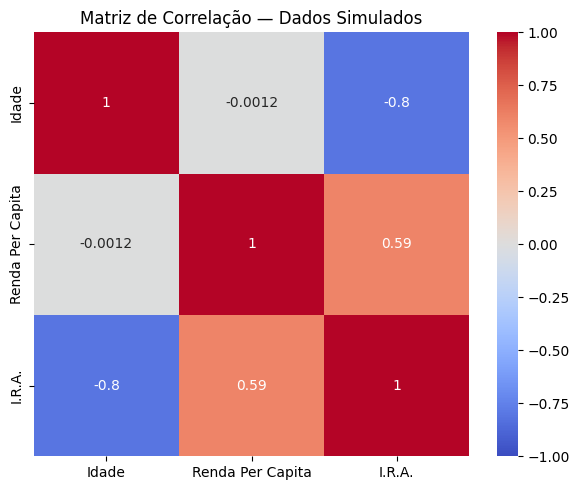

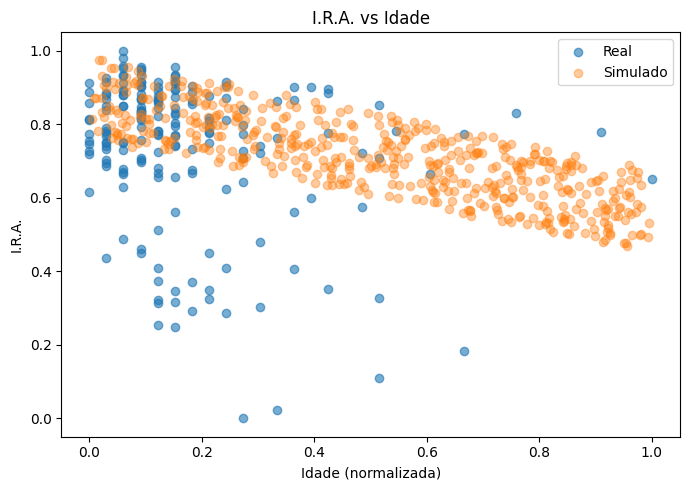

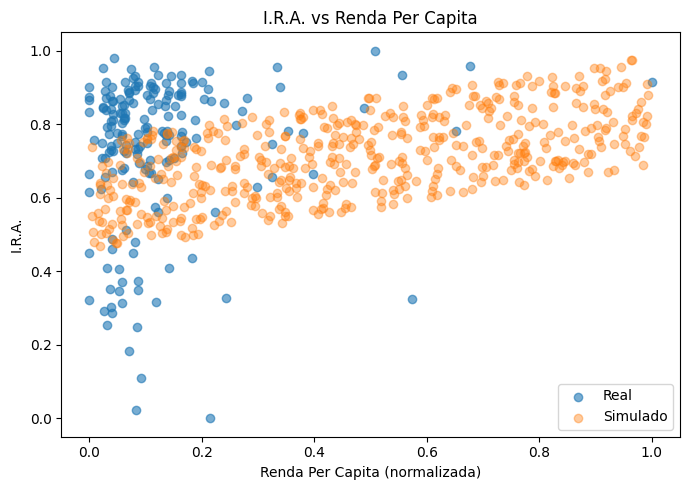

In [ ]:
# --- Matriz de Correlação Geral Simulada ---
colunas = ["I.R.A.", "Idade", "Renda Per Capita"]

df_matriz = df[colunas].copy()
df_matriz = df_matriz.apply(pd.to_numeric, errors='coerce')
df_matriz = df_matriz[df_matriz["I.R.A."] > 1]
df_matriz.dropna(inplace=True)

scaler = MinMaxScaler()
df_matriz[colunas] = scaler.fit_transform(df_matriz[colunas])

X = df_matriz[["Idade", "Renda Per Capita"]] # Variaveis
y = df_matriz["I.R.A."] # Variavel a ser simulada

modelo = LinearRegression() # cria um modelo com regressão linear para a relação estimada entre as variaveis x e y
modelo.fit(X, y)

n_simulados = 500

alunos_simulados = pd.DataFrame({
    "Idade": np.random.uniform(X["Idade"].min(), X["Idade"].max(), n_simulados), # atribui um valor aleatorio de idade para cada aluno simulado
    "Renda Per Capita": np.random.uniform(X["Renda Per Capita"].min(), X["Renda Per Capita"].max(), n_simulados) # atribui um valor aleatorio de renda per capita para cada aluno simulado
})

alunos_simulados["I.R.A."] = modelo.predict(alunos_simulados) # atribui a coluna ira o resultado simulado do I.R.A para cada aluno

# --- Cria uma matriz de correlação dos dados simulados ---
matriz_simulada = alunos_simulados.corr()
plt.figure(figsize=(6,5))
sns.heatmap(matriz_simulada, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de Correlação — Dados Simulados")
plt.tight_layout()
plt.savefig("Matriz_Correlacao_Simulada.pdf", format="pdf", bbox_inches='tight')
plt.show()
# --- Cria uma matriz de correlação dos dados simulados ---

# --- Cria uma tabela de comparação dos dados reais com os simulados I.R.A. X Idade ---
plt.figure(figsize=(7,5))
plt.scatter(df_matriz["Idade"], df_matriz["I.R.A."], alpha=0.6, label="Real")
plt.scatter(alunos_simulados["Idade"], alunos_simulados["I.R.A."], alpha=0.4, label="Simulado")
plt.xlabel("Idade (normalizada)")
plt.ylabel("I.R.A.")
plt.legend()
plt.title("I.R.A. vs Idade")
plt.tight_layout()
plt.savefig("IRA_vs_Idade.pdf", format="pdf", bbox_inches='tight')
plt.show()
# --- Cria uma tabela de comparação dos dados reais com os simulados I.R.A. X Idade ---

# --- Cria uma tabela de comparação dos dados reais com os simulados I.R.A. X Renda Per Capita ---
plt.figure(figsize=(7,5))
plt.scatter(df_matriz["Renda Per Capita"], df_matriz["I.R.A."], alpha=0.6, label="Real")
plt.scatter(alunos_simulados["Renda Per Capita"], alunos_simulados["I.R.A."], alpha=0.4, label="Simulado")
plt.xlabel("Renda Per Capita (normalizada)")
plt.ylabel("I.R.A.")
plt.legend()
plt.title("I.R.A. vs Renda Per Capita")
plt.tight_layout()
plt.savefig("IRA_vs_Renda.pdf", format="pdf", bbox_inches='tight')
plt.show()
# --- Cria uma tabela de comparação dos dados reais com os simulados I.R.A. X Renda Per Capita ---


🔹 Matriz de Correlação V de Cramer:
                              Sexo  Situação no Curso  Estado Civil  \
Sexo                      0.994046           0.000000      0.000000   
Situação no Curso         0.000000           1.000000      0.000000   
Estado Civil              0.000000           0.000000      1.000000   
Etnia/Raça                0.096465           0.102980      0.119743   
Cotista                   0.085587           0.212178      0.035367   
Tipo de Escola de Origem  0.000000           0.000000      0.196791   
codigo da cota            0.064944           0.000000      0.000000   

                          Etnia/Raça   Cotista  Tipo de Escola de Origem  \
Sexo                        0.096465  0.085587                  0.000000   
Situação no Curso           0.102980  0.212178                  0.000000   
Estado Civil                0.119743  0.035367                  0.196791   
Etnia/Raça                  1.000000  0.188109                  0.054866   
Cotista        

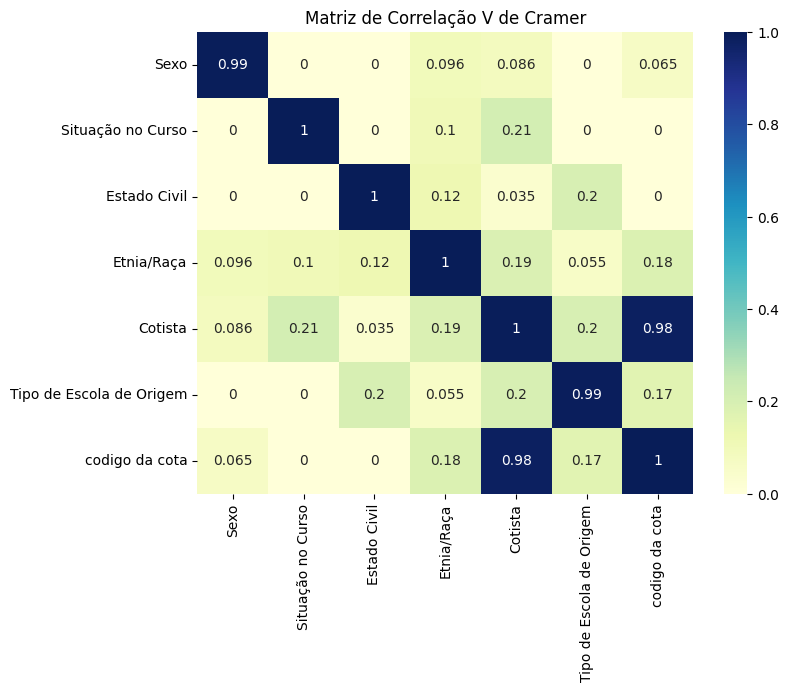

In [ ]:
# --- Matriz de Correlação Geral V de Cramer ---
colunas = ["Sexo", "Situação no Curso", "Estado Civil", "Etnia/Raça", "Cotista", "Tipo de Escola de Origem", "codigo da cota"]
df_teste = df[colunas].dropna().query('`Situação no Curso` not in ["Formado", "Jubilado", "Concluído"]')

# Função para calcular o V de Cramer entre duas colunas
def cramers_v(x, y):
    crosstable = pd.crosstab(x, y)
    chi2 = chi2_contingency(crosstable)[0]
    n = crosstable.sum().sum()
    phi2 = chi2 / n
    linhas, colunas = crosstable.shape
    corr_phi2 = max(0, phi2 - ((colunas-1)*(linhas-1)) / (n-1))
    corr_linhas = linhas - ((linhas-1)**2) / (n-1)
    corr_colunas = colunas - ((colunas-1)**2) / (n-1)
    return np.sqrt(corr_phi2 / min((corr_colunas-1), (corr_linhas-1)))

# Criar matriz de correlação de V de Cramer
colunas_df = df_teste.columns
matriz_v = pd.DataFrame(index=colunas_df, columns=colunas_df, dtype=float)

for col1 in colunas_df:
    for col2 in colunas_df:
        matriz_v.loc[col1, col2] = cramers_v(df[col1], df[col2])

# Cria o gráfico da matriz
print("🔹 Matriz de Correlação V de Cramer:")
print(matriz_v)
plt.figure(figsize=(8,6))
sns.heatmap(matriz_v.astype(float), annot=True, cmap="YlGnBu", vmin=0, vmax=1)
plt.title("Matriz de Correlação V de Cramer")
plt.savefig("Matriz_Correlação_Vcramer.pdf", format="pdf", bbox_inches='tight')
plt.show()
# --- Matriz de Correlação Geral V de Cramer ---

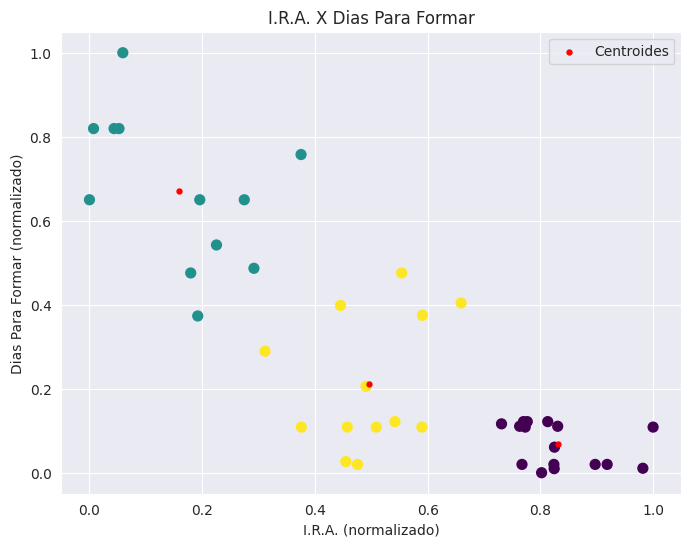

In [ ]:
# --- Dias Para Formar X I.R.A. ---
# Clusters KMeans
kmeans = KMeans(n_clusters=3, random_state=42) # inicia o Kmeans com 3 clusters
df_cluster_formados = df_formados.dropna(subset=["I.R.A.", "Dias Para Formar"])

scaler = MinMaxScaler() # Utiliaza oo Scaler para normalizar as variaveis não-categoricas
df_cluster_formados[["I.R.A.","Dias Para Formar"]] = scaler.fit_transform(df_cluster_formados[["I.R.A.","Dias Para Formar"]])

# Inicia o Data Frame dos clusters já retirando as linhas sem dados
df_cluster_formados["Cluster"] = kmeans.fit_predict(df_cluster_formados[["I.R.A.", "Dias Para Formar"]])

plt.figure(figsize=(8,6))
plt.scatter(df_cluster_formados["I.R.A."], df_cluster_formados["Dias Para Formar"], c=df_cluster_formados["Cluster"], cmap="viridis", s=50)
#desenha o centroides dos clusters
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], c='red', s=50, marker='.', label='Centroides')
plt.xlabel("I.R.A. (normalizado)")
plt.ylabel("Dias Para Formar (normalizado)")
plt.title("I.R.A. X Dias Para Formar")
plt.legend()
plt.savefig("dias_para_formar_x_I.R.A.pdf", format="pdf", bbox_inches='tight')
plt.show()
# --- cluster formados ---

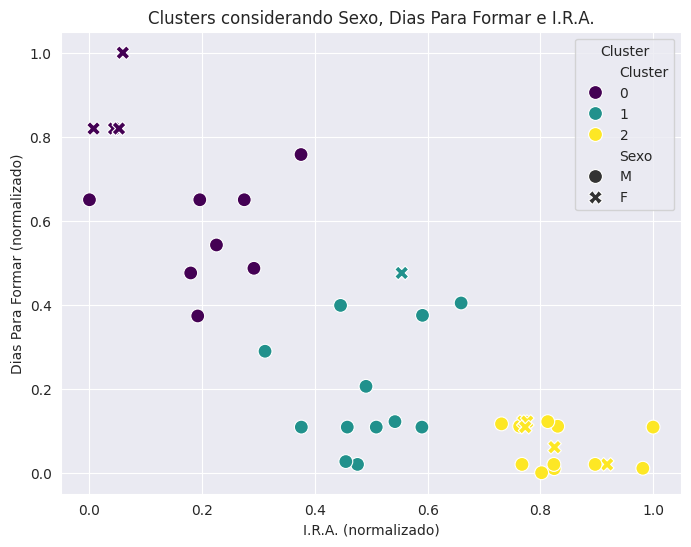

In [ ]:
# --- Dias Para formar X I.R.A. ---
# Cluster KPrototypes com diferenciação por sexo
colunas = ["Sexo", "I.R.A.","Dias Para Formar"]
df_cluster_formados = df_formados[colunas].dropna()

scaler = MinMaxScaler() # Utiliaza oo Scaler para normalizar as variaveis não-categoricas
df_cluster_formados[["I.R.A.","Dias Para Formar"]] = scaler.fit_transform(df_cluster_formados[["I.R.A.","Dias Para Formar"]])

kproto = KPrototypes(n_clusters=3, init='Cao', n_init=5, verbose=0, gamma = 0) # inicia o Kprototypes com 3 clusters
clusters = kproto.fit_predict(df_cluster_formados, categorical=[0])
df_cluster_formados['Cluster'] = clusters

# Cria o gráfico
sns.set_style('darkgrid')
plt.figure(figsize = (8, 6))
sns.scatterplot(
    data=df_cluster_formadoecho "# HorseProject" >> README.mds,
    x='I.R.A.',
    y='Dias Para Formar',
    hue='Cluster',
    style='Sexo', # Diferencia os pontos por sexo
    palette='viridis',
    s=100
)
plt.title('Clusters considerando Sexo, Dias Para Formar e I.R.A.')
plt.xlabel('I.R.A. (normalizado)')
plt.ylabel('Dias Para Formar (normalizado)')
plt.legend(title='Cluster')
plt.savefig("dias_para_formar_x_I.R.A_x_sexo.pdf", format="pdf", bbox_inches='tight')
plt.show()

# --- Dias Para formar X I.R.A. ---

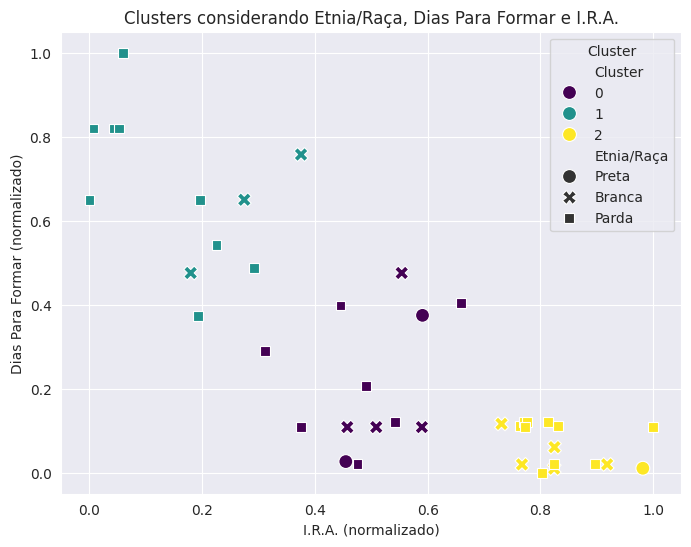

In [6]:
# --- Dias Para formar X I.R.A. ---
# Cluster KPrototypes com diferenciação por Etnia/Raça
colunas = ["Etnia/Raça", "I.R.A.","Dias Para Formar"]
df_cluster_formados = df_formados[colunas].dropna()

scaler = MinMaxScaler() # Utiliaza oo Scaler para normalizar as variaveis não-categoricas
df_cluster_formados[["I.R.A.","Dias Para Formar"]] = scaler.fit_transform(df_cluster_formados[["I.R.A.","Dias Para Formar"]])

kproto = KPrototypes(n_clusters=3, init='Cao', n_init=5, verbose=0, gamma = 0) # inicia o Kprototypes com 3 clusters
clusters = kproto.fit_predict(df_cluster_formados, categorical=[0])
df_cluster_formados['Cluster'] = clusters

# Cria o gráfico
sns.set_style('darkgrid')
plt.figure(figsize = (8, 6))
sns.scatterplot(
    data=df_cluster_formados,
    x='I.R.A.',
    y='Dias Para Formar',
    hue='Cluster',
    style='Etnia/Raça', # Diferencia os pontos por Etnia/Raça
    palette='viridis',
    s=100
)
plt.title('Clusters considerando Etnia/Raça, Dias Para Formar e I.R.A.')
plt.xlabel('I.R.A. (normalizado)')
plt.ylabel('Dias Para Formar (normalizado)')
plt.legend(title='Cluster')
plt.savefig("dias_para_formar_x_I.R.A_x_raça.pdf", format="pdf", bbox_inches='tight')
plt.show()

# --- Dias Para formar X I.R.A. ---

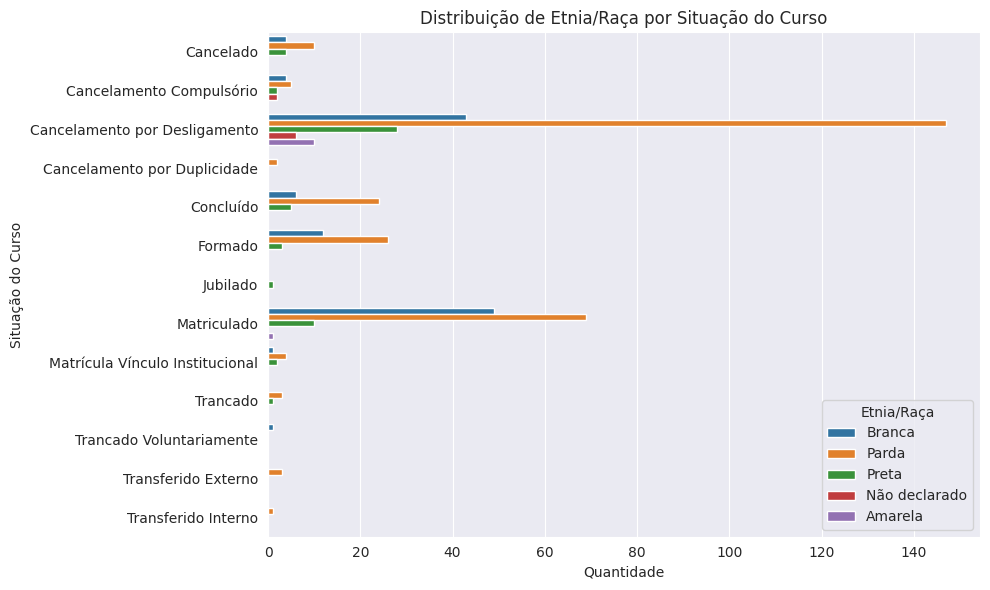

In [8]:
# --- Quantidade de pessoas de cada Etinia/Raça por situação do curso ---

colunas = ["Idade", "Sexo", "Situação no Curso",
           "Estado Civil", "Etnia/Raça", "Percentual de Progresso",
           "Cotista", "codigo da cota", "Renda Per Capita"]
df_teste = df[colunas].dropna().query('`Situação no Curso` not in ["Formado", "Jubilado", "Concluído"]')

df_grouped = df.groupby(['Situação no Curso', 'Etnia/Raça']).size().reset_index(name='quantidade')

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_grouped,
    x='quantidade',
    y='Situação no Curso',
    hue='Etnia/Raça'
)

plt.title('Distribuição de Etnia/Raça por Situação do Curso')
plt.ylabel('Situação do Curso')
plt.xlabel('Quantidade')
plt.legend(title='Etnia/Raça')
plt.tight_layout()
plt.savefig('Etnia_Raca_X_Situacao_do_Curso.pdf', format="pdf", bbox_inches='tight')
plt.show()

# --- Quantidade de pessoas de cada Etinia/Raça por situação do curso ---

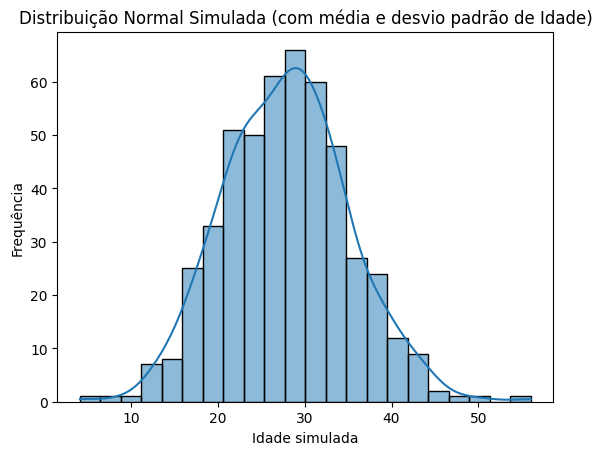

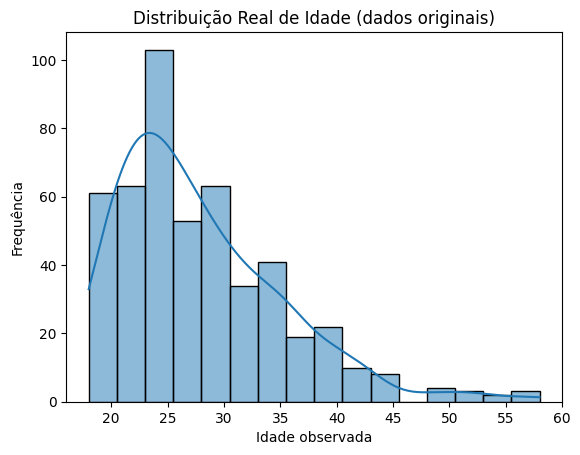

In [ ]:
# --- Distribuição Normal Idade ---
# Gerar amostras de uma distribuição normal
hist_idade = stats.norm.rvs(loc=df["Idade"].mean(), scale=df["Idade"].std(), size=df["Idade"].count(), random_state=42)

# Visualizar a distribuição
sns.histplot(hist_idade, kde=True)
plt.title('Distribuição Normal Simulada (com média e desvio padrão de Idade)')
plt.xlabel('Idade simulada')
plt.ylabel('Frequência')
plt.savefig("Distribuição_Normal_Simulada.pdf", format="pdf", bbox_inches='tight')
plt.show()

sns.histplot(df["Idade"], kde=True)
plt.title('Distribuição Real de Idade (dados originais)')
plt.xlabel('Idade observada')
plt.ylabel('Frequência')
plt.savefig("Distribuição_Real_Idade.pdf", format="pdf", bbox_inches='tight')
plt.show()
# --- Distribuição Normal Idade ---

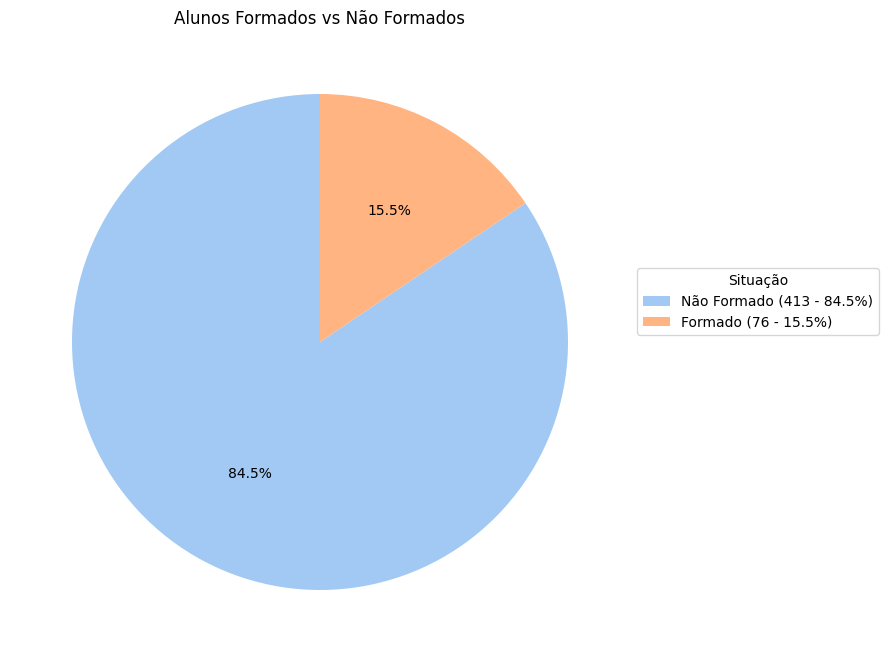

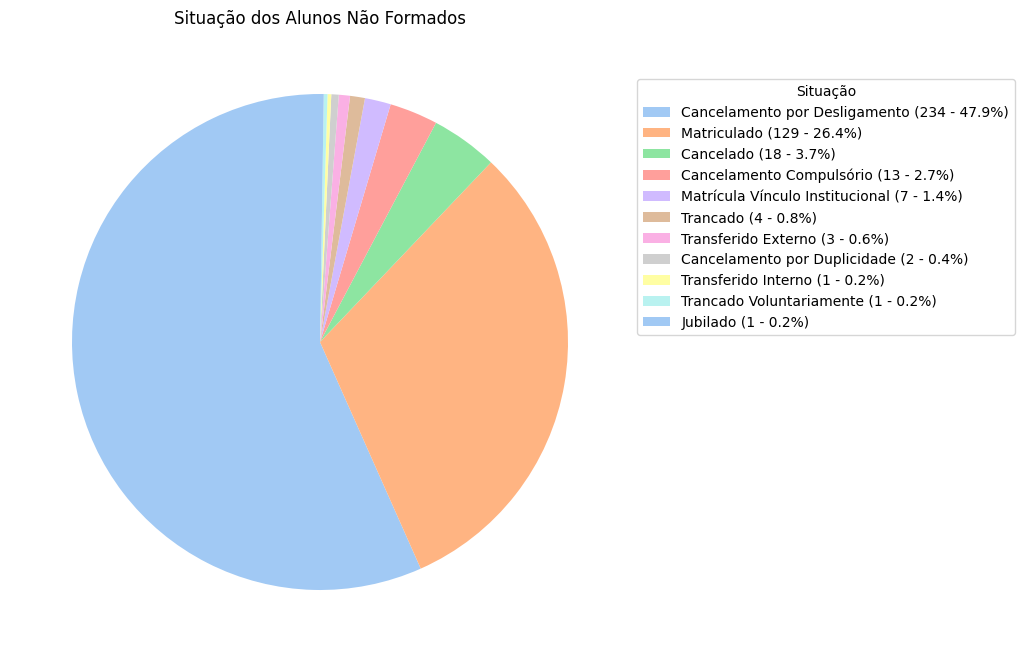

In [ ]:
colunas = ["Situação no Curso"]
df_populacao = df[colunas].dropna()
df_populacao['Situação'] = df_populacao['Situação no Curso'].apply(lambda x: 'Formado' if x in ['Formado', 'Concluído'] else 'Não Formado')

contagem = df_populacao['Situação'].value_counts()
total = contagem.sum()
label = [
    f"{situacao} ({valor} - {valor/total*100:.1f}%)"
    for situacao, valor in contagem.items()
]

#Gráfico Formados Vs Não Formados
cores = sns.color_palette("pastel")
fig, ax = plt.subplots(figsize=(8,12))
wedges, _, _ = ax.pie( contagem, autopct='%1.1f%%', colors=cores, startangle=90)
ax.legend(wedges, label, title="Situação", loc="lower left", bbox_to_anchor=(1, 0.5))
plt.title("Alunos Formados vs Não Formados")
plt.savefig("Alunos_Formados_vs_Não_Formados.pdf", format="pdf", bbox_inches='tight')
plt.show()


df_amostra = df_populacao[df_populacao['Situação'] == 'Não Formado']

situacoes = df_amostra['Situação no Curso'].value_counts()
total_sit = situacoes.sum()
label_sit = [
    f"{situacao} ({valor} - {valor/total*100:.1f}%)"
    for situacao, valor in situacoes.items()
]

#Gráfico da Situação dos Não Formados
fig, ax = plt.subplots(figsize=(8,12))
wedges, _, = ax.pie( situacoes, colors=cores, startangle=90)
ax.legend(wedges, label_sit, title="Situação", loc="lower left", bbox_to_anchor=(1, 0.5))
plt.title("Situação dos Alunos Não Formados")
plt.savefig("Situação_dos_Alunos_Não_Formados.pdf", format="pdf", bbox_inches='tight')
plt.show()